In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install -q torch torchvision datasets transformers wandb huggingface_hub scikit-learn seaborn

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sushantak17 (sushantak17-prom-iit-rajasthan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from huggingface_hub import hf_hub_download, upload_file, HfApi
import wandb

In [6]:

dataset = load_dataset("Chiranjeev007/STL-10_Subset")

train_ds = dataset["train"]
val_ds   = dataset["validation"]
test_ds  = dataset["test"]

class_names = train_ds.features["label"].names
num_classes = len(class_names)

print(class_names)

README.md:   0%|          | 0.00/723 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.82M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [8]:
class HFDataset(Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
train_loader = DataLoader(
    HFDataset(train_ds, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    HFDataset(val_ds, val_transform),
    batch_size=32
)

test_loader = DataLoader(
    HFDataset(test_ds, val_transform),
    batch_size=32
)

In [10]:
wandb.init(
    project="resnet18-hf-colab",
    config={"epochs":10,"batch_size":32}
)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [13]:
best_val_acc = 0
EPOCHS = 10

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss, correct, total = 0,0,0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)

        correct += (preds==labels).sum().item()
        total += labels.size(0)

    train_acc = correct/total
    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss, correct, total = 0,0,0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

    val_acc = correct/total
    val_loss /= len(val_loader)

    wandb.log({
        "train_loss":train_loss,
        "val_loss":val_loss,
        "train_acc":train_acc,
        "val_acc":val_acc
    })

    print(epoch, train_acc, val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),"best_model.pt")

0 0.8502 0.91
1 0.9538 0.934
2 0.973 0.932
3 0.9856 0.94
4 0.986 0.93
5 0.9928 0.928
6 0.99 0.926
7 0.9888 0.948
8 0.991 0.942
9 0.9926 0.924


In [14]:
repo_id = "Sushantak17/resnet18-best-model"

api = HfApi()
api.create_repo(repo_id, exist_ok=True)

upload_file(
    path_or_fileobj="best_model.pt",
    path_in_repo="best_model.pt",
    repo_id=repo_id
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  best_model.pt               :   1%|1         |  567kB / 44.8MB            

CommitInfo(commit_url='https://huggingface.co/Sushantak17/resnet18-best-model/commit/5ea78ecba09da0ced97025a78671e04f225ecb4a', commit_message='Upload best_model.pt with huggingface_hub', commit_description='', oid='5ea78ecba09da0ced97025a78671e04f225ecb4a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Sushantak17/resnet18-best-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Sushantak17/resnet18-best-model'), pr_revision=None, pr_num=None)

In [15]:
model_path = hf_hub_download(
    repo_id=repo_id,
    filename="best_model.pt"
)

model.load_state_dict(torch.load(model_path))
model.eval()

best_model.pt:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
all_preds=[]
all_labels=[]
all_images=[]

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_images.extend(images.cpu())

In [17]:
wandb.log({
    "confusion_matrix":
    wandb.plot.confusion_matrix(
        preds=all_preds,
        y_true=all_labels,
        class_names=class_names
    )
})

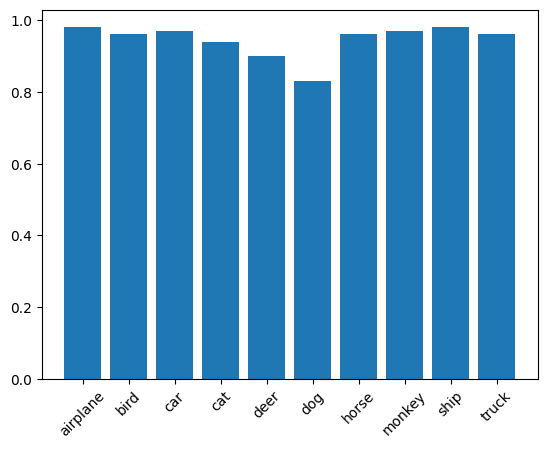

In [18]:
class_correct=np.zeros(num_classes)
class_total=np.zeros(num_classes)

for p,l in zip(all_preds,all_labels):
    class_total[l]+=1
    if p==l:
        class_correct[l]+=1

class_acc=class_correct/class_total

plt.figure()
plt.bar(class_names,class_acc)
plt.xticks(rotation=45)

wandb.log({"classwise_accuracy":wandb.Image(plt)})

In [19]:
correct_samples=[]
incorrect_samples=[]

for img,p,l in zip(all_images,all_preds,all_labels):

    if p==l and len(correct_samples)<10:
        correct_samples.append((img,p,l))

    if p!=l and len(incorrect_samples)<10:
        incorrect_samples.append((img,p,l))

    if len(correct_samples)==10 and len(incorrect_samples)==10:
        break

In [20]:
def log_samples(samples,title):

    table=wandb.Table(columns=["image","pred","actual"])

    for img,p,l in samples:
        img=img.permute(1,2,0).numpy()

        table.add_data(
            wandb.Image(img),
            class_names[p],
            class_names[l]
        )

    wandb.log({title:table})

log_samples(correct_samples,"correct_predictions")
log_samples(incorrect_samples,"incorrect_predictions")

wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.
